I've encountered some weird results when going through the perturbation theory for multiple atoms, so I want to create a fresh notebook for checking that the calculations make sense.  The case of two level atoms is very straightforward and I think we have a solid grasp of the theory, so we'll ignore that for now and start by considering the case of three level atoms.

### Imports and Setup

In [1]:
import numpy as np
import qutip as qu
import matplotlib.pyplot as plt
from scipy import linalg
import sympy as sym

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

### Functions

In [3]:
def inv_pert_theory(eig_ind, eigenstuff, H, V, λ, δL=0):
    """
    Function for calculating the perturbed eigenstates of a system to first order using matrix inversion
    :param eig_ind:    the index of the eigenstate that is being perturbed
    :param eigenstuff: the eigenstates and eigenvalues of the unperturbed system
    :param H:          the Hamiltonian
    :param V:          the perturbation
    :param λ:          the scaling parameter for the strength of the perturbation
    :param δL:         detuning parameter between the laser adding the perturbation and the cavity mode
    :return:           the perturbed eigenstate to first order
    """
    # Get the zeroth order correction
    nu0 = eigenstuff[1][eig_ind]

    # Define the matrix to be inverted
    A = (δL + eigenstuff[0][eig_ind]) * qu.qeye(H.dims[0]) - H

    # Get the first order correction
    nu1 = A.inv() * V * nu0

    # return
    return nu0 + λ * nu1

In [4]:
def trad_pert_theory(eig_ind, eigenstuff, left_eigenstuff, H, V, λ, δL=0):
    """
    Function for calculating the perturbed eigenstates of a system to first order using the traditional approach
    :param eig_ind:         the index of the eigenstate that is being perturbed
    :param eigenstuff:      the eigenstates and eigenvalues of the unperturbed system
    :param left_eigenstuff: the left eigenstates and eigenvalues of the unperturbed system for non-Hermitian H
    :param H:               the Hamiltonian
    :param V:               the perturbation
    :param λ:               the scaling parameter for the strength of the perturbation
    :param δL:              detuning parameter between the laser adding the perturbation and the cavity mode
    :return:                the perturbed eigenstate to first order
    """
    # Get the zeroth order correction
    nu0 = eigenstuff[1][eig_ind]

    # Loop over eigenstates
    nu1 = 0
    for i in range(eigenstuff[0].shape[0]):
        if i != eig_ind:
            scal_prod = left_eigenstuff[1][i].dag() * V * eigenstuff[1][eig_ind]
            energy_diff = eigenstuff[0][i] - eigenstuff[0][eig_ind]
            nu1 += scal_prod / energy_diff * eigenstuff[1][i]

    # Return 
    return nu0 - λ * nu1
            

### Single Atom
It might be useful to have a schematic to refer to for how the basis states are arranged in this problem.  We have for the atomic states,
$$\begin{pmatrix}|0,0\rangle\langle0,0| & |0,0\rangle\langle0,1| & |0,0\rangle\langle0,2| \\|0,1\rangle\langle0,0| & |0,1\rangle\langle0,1| & |0,1\rangle\langle0,2| \\|0,2\rangle\langle0,0| & |0,2\rangle\langle0,1| & |0,2\rangle\langle0,2|\end{pmatrix}$$

In [5]:
# Define parameters - we'll assume zero detuning for now
g10 = 10
g21 = 1
κ = 1
γ10 = 1
γ21 = 0.05

In [6]:
# Define the atomic operators that we'll need
σ10 = qu.Qobj([[0, 1, 0],
               [0, 0, 0],
               [0, 0, 0]])
σ21 = qu.Qobj([[0, 0, 0],
               [0, 0, 1],
               [0, 0, 0]])

# Now define the cavity operator
a = qu.destroy(2)

# Define identity operators representing the cavity and atomic spaces for ease of use
Ic = qu.qeye(2)
I0 = qu.qeye(3)

In [7]:
# Define the Hamiltonian using the operators above
H = -1j*κ * qu.tensor(a.dag() * a, I0) -1j*γ10 * qu.tensor(Ic, σ10.dag() * σ10) - 1j*γ21 * qu.tensor(Ic, σ21.dag() * σ21)
H += g21 * (qu.tensor(a, σ21.dag()) + qu.tensor(a.dag(), σ21)) + g10 * (qu.tensor(Ic, σ10.dag()) + qu.tensor(Ic, σ10))

# Get the eigenstates of H
H_eigs = H.eigenstates()

# Also get the left eigenstates of H
left_H_eigs = H.dag().eigenstates()

# Print H
H

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[ 0.+0.j   10.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [10.+0.j    0.-1.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.-0.05j  0.+0.j    1.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.-1.j   10.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    1.+0.j   10.+0.j    0.-2.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.-1.05j]]

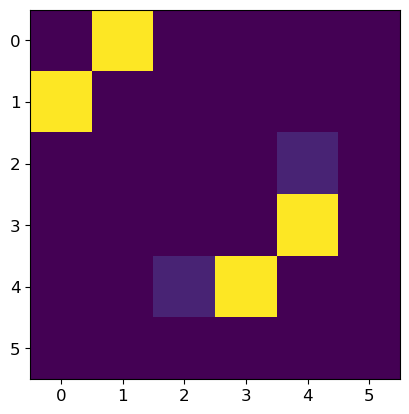

In [8]:
plt.imshow(H.full().real)

In [9]:
# Define the basis states that we'll need to create Hu and Hp
cav_bas = [qu.basis(2, i) for i in range(2)]

atom_bas = [qu.basis(3, i) for i in range(3)]

In [10]:
# Define basis for Hu
Hu_bas = [qu.tensor(cav_bas[0], atom_bas[i]) for i in range(2)]

# Now construct the matrix
Hu_mat = np.zeros((len(Hu_bas), len(Hu_bas)), dtype=complex)
for i in range(len(Hu_bas)):
    for j in range(len(Hu_bas)):
        Hu_mat[i][j] = Hu_bas[i].dag() * H * Hu_bas[j]

# Now turn this into a Qobj
Hu = qu.Qobj(Hu_mat)
Hu

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.+0.j 10.+0.j]
 [10.+0.j  0.-1.j]]

In [11]:
# Get the eigenstates for Hu
Hu_eigs = Hu.eigenstates()

In [12]:
# Define basis for Hp
Hp_bas = [qu.tensor(cav_bas[1], atom_bas[i]) for i in range(2)]
Hp_bas.insert(0, qu.tensor(cav_bas[0], atom_bas[2]))

# Construct the matrix
Hp_mat = np.zeros((len(Hp_bas), len(Hp_bas)), dtype=complex)
for i in range(len(Hp_bas)):
    for j in range(len(Hp_bas)):
        Hp_mat[i][j] = Hp_bas[i].dag() * H * Hp_bas[j]

# Now turn this into a Qobj
Hp = qu.Qobj(Hp_mat)
Hp

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.-0.05j  0.+0.j    1.+0.j  ]
 [ 0.+0.j    0.-1.j   10.+0.j  ]
 [ 1.+0.j   10.+0.j    0.-2.j  ]]

In [13]:
Hp_eigs = Hp.eigenstates()

In [14]:
# Now let's verify that the eigenvalues of Hu and Hp are in the eigenvalues of H
print("Hu eigenvalues: \n", Hu_eigs[0])
print("Hp eigenvalues: \n", Hp_eigs[0])
print("H eigenvalues: \n", H_eigs[0])

Hu eigenvalues: 
 [-9.98749218-0.5j  9.98749218-0.5j]
Hp eigenvalues: 
 [-1.00367658e+01-1.49538054j -3.76434994e-16-0.05923893j
  1.00367658e+01-1.49538054j]
H eigenvalues: 
 [-1.00367658e+01-1.49538054j -9.98749218e+00-0.5j
 -3.76434994e-16-0.05923893j  0.00000000e+00-1.05j
  9.98749218e+00-0.5j         1.00367658e+01-1.49538054j]


In [15]:
# Let's also verify that the eigenvectors of Hu and Hp are the eigenvectors of H
# Do Hu first
print("Hu eigenvectors: \n", Hu_eigs[1][0], '\n', Hu_eigs[1][1])
print("H eigenvectors (1 and 4): \n", H_eigs[1][1], '\n', H_eigs[1][4])

Hu eigenvectors: 
 Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-0.70622234+0.03535534j]
 [ 0.70710678+0.j        ]] 
 Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678+0.j        ]
 [0.70622234-0.03535534j]]
H eigenvectors (1 and 4): 
 Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
Qobj data =
[[-0.70622234+0.03535534j]
 [ 0.70710678+0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]] 
 Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70710678+0.j        ]
 [ 0.70622234-0.03535534j]
 [-0.        +0.j        ]
 [-0.        +0.j        ]
 [-0.        +0.j        ]
 [-0.        +0.j        ]]


In [16]:
# Now do Hp
print("Hp eigenvectors: \n", Hp_eigs[1][0], '\n', Hp_eigs[1][1], '\n', Hp_eigs[1][2])
print("H eigenvectors (0, 2, and 5): \n", H_eigs[1][0], '\n', H_eigs[1][2], '\n', H_eigs[1][5])

Hp eigenvectors: 
 Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[-0.06902028+0.00993951j]
 [-0.70280449+0.03468803j]
 [ 0.70710678+0.j        ]] 
 Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 9.95170236e-01+0.00000000e+00j]
 [-9.77326286e-02-3.12250226e-17j]
 [-1.09504419e-16-9.19430525e-03j]] 
 Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[0.06902028+0.00993951j]
 [0.70280449+0.03468803j]
 [0.70710678+0.j        ]]
H eigenvectors (0, 2, and 5): 
 Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [-0.06902028+0.00993951j]
 [-0.70280449+0.03468803j]
 [ 0.70710678+0.j        ]
 [ 0.        +0.j        ]] 
 Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
Qobj data =
[[-0.00000000e+00+0.00000000e+00j]
 [-0.00000000e+00+0.00000000e+00j]
 [ 9.95170236e-01+0.00

Now I want to verify that our usual way of calculating the perturbed state matches with the exact result.

In [17]:
# Define our perturbation
V = qu.tensor(cav_bas[1], atom_bas[0]) * qu.tensor(cav_bas[0], atom_bas[0]).dag()
V += qu.tensor(cav_bas[1], atom_bas[1]) * qu.tensor(cav_bas[0], atom_bas[1]).dag()
V += V.dag()
V

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

In [18]:
# Calculate the perturbed Hamiltonian
λ = 1e-3
Ht = H + λ*V
Ht

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0.e+00+0.j   1.e+01+0.j   0.e+00+0.j   1.e-03+0.j   0.e+00+0.j
  0.e+00+0.j  ]
 [1.e+01+0.j   0.e+00-1.j   0.e+00+0.j   0.e+00+0.j   1.e-03+0.j
  0.e+00+0.j  ]
 [0.e+00+0.j   0.e+00+0.j   0.e+00-0.05j 0.e+00+0.j   1.e+00+0.j
  0.e+00+0.j  ]
 [1.e-03+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00-1.j   1.e+01+0.j
  0.e+00+0.j  ]
 [0.e+00+0.j   1.e-03+0.j   1.e+00+0.j   1.e+01+0.j   0.e+00-2.j
  0.e+00+0.j  ]
 [0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j
  0.e+00-1.05j]]

In [19]:
# Get the eigenstates under this perturbation
pert_eigs = Ht.eigenstates()

In [20]:
# Compare the eigenvalues - they should be the same because the first order correction is 0
print("Original eigenvalues: \n", H_eigs[0])
print("Perturbed eigenvalues: \n", pert_eigs[0])

Original eigenvalues: 
 [-1.00367658e+01-1.49538054j -9.98749218e+00-0.5j
 -3.76434994e-16-0.05923893j  0.00000000e+00-1.05j
  9.98749218e+00-0.5j         1.00367658e+01-1.49538054j]
Perturbed eigenvalues: 
 [-1.00367658e+01-1.49537954j -9.98749213e+00-0.500001j
  0.00000000e+00-1.05j        3.01582327e-19-0.05923893j
  9.98749213e+00-0.500001j    1.00367658e+01-1.49537954j]


It seems that the built in eigensolvers opt to arrange the coefficients of the eigenstates differently for the perturbed Hamiltonian compared to the unperturbed Hamiltonian.  This makes comparing the results obtained using perturbation theory a bit annoying.  One thing that we can do is renormalize our eigenvectors so that the maximum element of each is 1.  This should avoid this problem.

In [21]:
# Create lists for storing the eigenvectors obtained using perturbation theory
inv_nuλ = []
trad_nuλ = []

# Loop over the eigenstates and calculate each using perturbation theory
for i in [1, 4]:
    inv_nuλ.append(inv_pert_theory(i, H_eigs, H, V, λ))
    trad_nuλ.append(trad_pert_theory(i, H_eigs, left_H_eigs, H, V, λ))

In [22]:
trad_nuλ[0] / trad_nuλ[0].full().T[0][0]

Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
Qobj data =
[[ 1.00000000e+00+6.93889390e-18j]
 [-9.98749218e-01-5.00000000e-02j]
 [ 5.71482719e-07-9.95026891e-05j]
 [-2.22225786e-07-9.94691736e-04j]
 [-4.97945839e-05+9.98425720e-04j]
 [ 0.00000000e+00-0.00000000e+00j]]

In [23]:
pert_eigs[1][1] / pert_eigs[1][1].full().T[0][0]

Quantum object: dims=[[2, 3], [1]], shape=(6, 1), type='ket', dtype=Dense
Qobj data =
[[ 1.00000000e+00+0.00000000e+00j]
 [-9.98749218e-01-5.00000002e-02j]
 [ 5.50675540e-06-9.99725315e-05j]
 [ 4.97861750e-05-9.94751745e-04j]
 [-9.99864150e-05+9.95996826e-04j]
 [ 0.00000000e+00+0.00000000e+00j]]

In [24]:
print("Norm difference for first eigenstate: ")
print((trad_nuλ[0] / trad_nuλ[0].full().T[0][0] - pert_eigs[1][1] / pert_eigs[1][1].full().T[pert_eigs[1][1].full().T != 0][0]).norm())

Norm difference for first eigenstate: 
7.106715739403684e-05


In [25]:
print("Norm difference for second eigenstate: ")
print((trad_nuλ[1] / trad_nuλ[1].full().T[0][0] - pert_eigs[1][4] / pert_eigs[1][4].full().T[pert_eigs[1][4].full().T != 0][0]).norm())

Norm difference for second eigenstate: 
7.106715739401242e-05


How do these results compare to those obtained using the inversion approach?

In [26]:
print("Norm difference for first eigenstate: ")
print((inv_nuλ[0] / inv_nuλ[0].full().T[0][0] - pert_eigs[1][1] / pert_eigs[1][1].full().T[pert_eigs[1][1].full().T != 0][0]).norm())

Norm difference for first eigenstate: 
1.4404142682397193e-09


In [27]:
print("Norm difference for second eigenstate: ")
print((inv_nuλ[1] / inv_nuλ[1].full().T[0][0] - pert_eigs[1][4] / pert_eigs[1][4].full().T[pert_eigs[1][4].full().T != 0][0]).norm())

Norm difference for second eigenstate: 
1.440414276401839e-09


So the results obtained by inverting the matrix are more accurate.  This is what we expected because there's no taking the expression in terms of $\lambda$ and dropping terms if you can invert the matrix.

### Two Atoms
Now we want to confirm that this works with two atoms.  This should be very straightforward.  We'll assume for now that the detunings are all the same and set them to zero for simplicity.

In [28]:
# Let's define a new identity matrix to represent the second atom
I1 = qu.qeye(3)

In [29]:
# Define the two atom Hamiltonian
H2 = -1j*κ * qu.tensor([a.dag() * a, I0, I1])
H2 += -1j*γ10 * (qu.tensor([Ic, σ10.dag() * σ10, I1]) + qu.tensor([Ic, I0, σ10.dag() * σ10]))
H2 += -1j*γ21 * (qu.tensor([Ic, σ21.dag() * σ21, I1]) + qu.tensor([Ic, I0, σ21.dag() * σ21]))
H2 += g10 * (qu.tensor([Ic, σ10.dag(), I1]) + qu.tensor([Ic, I0, σ10.dag()]) + qu.tensor([Ic, σ10, I1]) + qu.tensor([Ic, I0, σ10]))
H2 += g21 * (qu.tensor([a, σ21.dag(), I1]) + qu.tensor([a, I0, σ21.dag()]) + qu.tensor([a.dag(), σ21, I1]) + qu.tensor([a.dag(), I0, σ21]))
H2

Quantum object: dims=[[2, 3, 3], [2, 3, 3]], shape=(18, 18), type='oper', dtype=Dia, isherm=False
Qobj data =
[[ 0.+0.j   10.+0.j    0.+0.j   10.+0.j    0.+0.j    0.+0.j    0.+0.j
   0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j
   0.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [10.+0.j    0.-1.j    0.+0.j    0.+0.j   10.+0.j    0.+0.j    0.+0.j
   0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j
   0.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.-0.05j  0.+0.j    0.+0.j   10.+0.j    0.+0.j
   0.+0.j    0.+0.j    0.+0.j    1.+0.j    0.+0.j    0.+0.j    0.+0.j
   0.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [10.+0.j    0.+0.j    0.+0.j    0.-1.j   10.+0.j    0.+0.j    0.+0.j
   0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j
   0.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j   10.+0.j    0.+0.j   10.+0.j    0.-2.j    0.+0.j    0.+0.j
   0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j
   0.+0.j    0.+0.

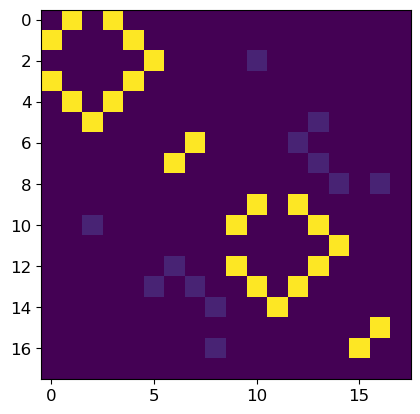

In [30]:
plt.imshow(H2.full().real)

In [31]:
H2_eigs = H2.eigenstates()
H2_left_eigs = H2.dag().eigenstates()
H2_eigs

(array([-2.00730791e+01-1.99091462j, -1.99749844e+01-1.j        ,
        -1.00858173e+01-1.54084776j, -1.00367658e+01-0.55461946j,
        -9.98749218e+00-1.55j      , -9.93890670e+00-0.56377428j,
         0.00000000e+00-1.1j       ,  0.00000000e+00-1.j        ,
         2.15154151e-16-1.99076107j,  2.22044805e-16-1.9906222j ,
         2.39391840e-16-0.11830448j,  5.28121136e-15-1.j        ,
         9.93890670e+00-0.56377428j,  9.98749218e+00-1.55j      ,
         1.00367658e+01-0.55461946j,  1.00858173e+01-1.54084776j,
         1.99749844e+01-1.j        ,  2.00730791e+01-1.99091462j]),
 array([Quantum object: dims=[[2, 3, 3], [1]], shape=(18, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 4.28672830e-36+2.98986468e-35j]
         [-1.28781001e-33-2.88038952e-33j]
         [ 4.80260718e-02-9.30937683e-03j]
         [ 1.80690324e-33+3.34971908e-33j]
         [-1.68079477e-36+3.07506793e-35j]
         [-4.85112069e-02+6.91167865e-03j]
         [ 4.80260718e-02-9.30937683e-03

In [32]:
# Now define the basis for Hu with 2 atoms
H2u_bas = []

for i in range(len(atom_bas)-1):
    for j in range(len(atom_bas)-1):
        H2u_bas.append(qu.tensor([cav_bas[0], atom_bas[i], atom_bas[j]]))

In [33]:
# Now create the blank matrix for storing Hu
H2u_mat = np.zeros((len(H2u_bas), len(H2u_bas)), dtype=complex)

# Loop and fill in the matrix
for i in range(len(H2u_bas)):
    for j in range(len(H2u_bas)):
        H2u_mat[i][j] = H2u_bas[i].dag() * H2 * H2u_bas[j]

H2u = qu.Qobj(H2u_mat)
H2u

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.+0.j 10.+0.j 10.+0.j  0.+0.j]
 [10.+0.j  0.-1.j  0.+0.j 10.+0.j]
 [10.+0.j  0.+0.j  0.-1.j 10.+0.j]
 [ 0.+0.j 10.+0.j 10.+0.j  0.-2.j]]

In [34]:
H2u.eigenstates()

(array([-1.99749844e+01-1.j,  0.00000000e+00-1.j,  5.28121136e-15-1.j,
         1.99749844e+01-1.j]),
 array([Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.49937461+0.025j]
         [ 0.5       +0.j   ]
         [ 0.5       +0.j   ]
         [-0.49937461-0.025j]]                                                ,
        Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.00071356+1.50044018e-04j]
         [-0.7070989 -7.13564396e-05j]
         [ 0.70711391+0.00000000e+00j]
         [-0.00071356-1.50044018e-04j]]                                       ,
        Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[-7.06224552e-01+2.77555756e-17j]
         [ 3.46944695e-17+3.53112276e-02j]
         [ 3.44776291e-17+3.53112276e-02j]
         [ 7.06224552e-01+0.00000000e+00j]]                                   ,
        Quantum object: d

Actually, I'm not sure that I really need to separate things into $H_u$ and $H_p$ here.  I'll leave what I have for $H_u$ as a potentially useful reference for later, but I won't go about doing the same for $H_p$ yet.  Instead, we'll just go ahead with solving the perturbation theory as before.  To define the perturbation, we have $V = |1,0,0\rangle\langle 0, 0, 0| + |0,0,0\rangle\langle1,0,0| + |1,0,1\rangle\langle0,0,1| + |0,0,1\rangle\langle1,0,1| + \cdots$.  It should be possible to implement this by looping over our atomic bases.

In [35]:
# Define our perturbation
V2 = 0
for i in range(len(atom_bas)-1):
    for j in range(len(atom_bas)-1):
        V2 += qu.tensor([cav_bas[1], atom_bas[i], atom_bas[j]]) * qu.tensor([cav_bas[0], atom_bas[i], atom_bas[j]]).dag()
V2 += V2.dag()
V2

Quantum object: dims=[[2, 3, 3], [2, 3, 3]], shape=(18, 18), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [36]:
# Define the perturbed Hamiltonian
H2t = H2 + λ * V2
H2t

Quantum object: dims=[[2, 3, 3], [2, 3, 3]], shape=(18, 18), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0.e+00+0.j   1.e+01+0.j   0.e+00+0.j   1.e+01+0.j   0.e+00+0.j
  0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   1.e-03+0.j
  0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j
  0.e+00+0.j   0.e+00+0.j   0.e+00+0.j  ]
 [1.e+01+0.j   0.e+00-1.j   0.e+00+0.j   0.e+00+0.j   1.e+01+0.j
  0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j
  1.e-03+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j
  0.e+00+0.j   0.e+00+0.j   0.e+00+0.j  ]
 [0.e+00+0.j   0.e+00+0.j   0.e+00-0.05j 0.e+00+0.j   0.e+00+0.j
  1.e+01+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j
  1.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j
  0.e+00+0.j   0.e+00+0.j   0.e+00+0.j  ]
 [1.e+01+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00-1.j   1.e+01+0.j
  0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j   0.e+00+0.j
  0.e+00+0.j   0.e+00+0.j   1.e-03+0.j   0.e+00+0

In [37]:
# Get the eigenstates of the perturbed Hamiltonian
H2t_eigs = H2t.eigenstates()
H2t_eigs[1][1]

Quantum object: dims=[[2, 3, 3], [1]], shape=(18, 1), type='ket', dtype=Dense
Qobj data =
[[ 4.99999750e-01+0.00000000e+00j]
 [-4.99374359e-01-2.49999876e-02j]
 [ 5.21296848e-06-4.95473684e-05j]
 [-4.99374359e-01-2.49999876e-02j]
 [ 4.97499751e-01+4.99374362e-02j]
 [-7.69955231e-06+4.93065857e-05j]
 [ 5.21296848e-06-4.95473684e-05j]
 [-7.69955231e-06+4.93065857e-05j]
 [-2.46572835e-35-6.93661853e-36j]
 [ 4.92650975e-05-4.92305494e-04j]
 [-7.42034893e-05+4.91689722e-04j]
 [-9.50931598e-37-3.44616884e-37j]
 [-7.42034893e-05+4.91689722e-04j]
 [ 9.92034709e-05-4.89809558e-04j]
 [ 1.88946775e-36+6.85162330e-37j]
 [-9.39809962e-37-3.50208028e-37j]
 [ 1.88199200e-36+6.94452904e-37j]
 [ 0.00000000e+00+0.00000000e+00j]]

It looks like the second eigenstate of $H_2$ corresponds to the unperturbed basis because it matches up pretty well with the first eigenstate of $H_{2U}$.  It's a little off because the third coefficient corresponds to the state $|0, 0, 2\rangle$, which isn't a part of the basis of $H_{2U}$.  There's probably a way to rearrange the basis so they line up better, but I'm not sure how easy that would be to implement going forward.  Regardless, we should be able to apply our perturabation theory to this eigenstate to obtain the perturbed eigenstate, and it should be pretty close to the second eigenstate of $H_{2t}$ above.

In [38]:
# Get the results from perturbation theory using inversion and the scalar product formulation
inv_nuλ2 = inv_pert_theory(1, H2_eigs, H2, V2, λ, δL=0)
trad_nuλ2 = trad_pert_theory(1, H2_eigs, H2_left_eigs, H2, V2, λ, δL=0)

In [39]:
renorm_inv_nuλ2 = inv_nuλ2 / inv_nuλ2.full().T[0][0]
renorm_inv_nuλ2

Quantum object: dims=[[2, 3, 3], [1]], shape=(18, 1), type='ket', dtype=Dense
Qobj data =
[[ 1.00000000e+00+0.00000000e+00j]
 [-9.98749218e-01-5.00000000e-02j]
 [ 1.04259221e-05-9.90946898e-05j]
 [-9.98749218e-01-5.00000000e-02j]
 [ 9.95000000e-01+9.98749218e-02j]
 [-1.53990874e-05+9.86131250e-05j]
 [ 1.04259221e-05-9.90946898e-05j]
 [-1.53990874e-05+9.86131250e-05j]
 [ 0.00000000e+00-0.00000000e+00j]
 [ 9.85299518e-05-9.84610536e-04j]
 [-1.48406712e-04+9.83379003e-04j]
 [ 0.00000000e+00-0.00000000e+00j]
 [-1.48406712e-04+9.83379003e-04j]
 [ 1.98406653e-04-9.79618686e-04j]
 [ 0.00000000e+00-0.00000000e+00j]
 [ 0.00000000e+00-0.00000000e+00j]
 [ 0.00000000e+00-0.00000000e+00j]
 [ 0.00000000e+00-0.00000000e+00j]]

In [40]:
renorm_trad_nuλ2 = trad_nuλ2 / trad_nuλ2.full().T[0][0]
renorm_trad_nuλ2

Quantum object: dims=[[2, 3, 3], [1]], shape=(18, 1), type='ket', dtype=Dense
Qobj data =
[[ 1.00000000e+00+0.00000000e+00j]
 [-9.98749218e-01-5.00000000e-02j]
 [ 5.47847529e-07-9.89137656e-05j]
 [-9.98749218e-01-5.00000000e-02j]
 [ 9.95000000e-01+9.98749218e-02j]
 [-5.50823399e-06+9.89274591e-05j]
 [ 5.47847529e-07-9.89137656e-05j]
 [-5.50823399e-06+9.89274591e-05j]
 [ 7.65768138e-22+1.05415307e-21j]
 [-6.92163786e-07-9.86942281e-04j]
 [-4.89364277e-05+9.90685151e-04j]
 [ 1.51241891e-21+1.68596833e-22j]
 [-4.89364277e-05+9.90685151e-04j]
 [ 9.89378653e-05-9.91929921e-04j]
 [-1.54609371e-21-2.26066547e-22j]
 [ 1.84081356e-21+1.22062480e-22j]
 [-1.82864426e-21-2.09173675e-22j]
 [ 0.00000000e+00-0.00000000e+00j]]

In [41]:
renorm_H2t_ex = H2t_eigs[1][1] / H2t_eigs[1][1].full().T[0][0]
renorm_H2t_ex

Quantum object: dims=[[2, 3, 3], [1]], shape=(18, 1), type='ket', dtype=Dense
Qobj data =
[[ 1.00000000e+00+0.00000000e+00j]
 [-9.98749218e-01-5.00000002e-02j]
 [ 1.04259422e-05-9.90947864e-05j]
 [-9.98749218e-01-5.00000002e-02j]
 [ 9.95000000e-01+9.98749223e-02j]
 [-1.53991123e-05+9.86132206e-05j]
 [ 1.04259422e-05-9.90947864e-05j]
 [-1.53991123e-05+9.86132206e-05j]
 [-4.93145917e-35-1.38732440e-35j]
 [ 9.85302443e-05-9.84611480e-04j]
 [-1.48407053e-04+9.83379936e-04j]
 [-1.90186415e-36-6.89234113e-37j]
 [-1.48407053e-04+9.83379936e-04j]
 [ 1.98407041e-04-9.79619606e-04j]
 [ 3.77893740e-36+1.37032534e-36j]
 [-1.87962086e-36-7.00416405e-37j]
 [ 3.76398589e-36+1.38890650e-36j]
 [ 0.00000000e+00+0.00000000e+00j]]

In [42]:
# Print the norm differences
inv_norm_diff = (renorm_inv_nuλ2 - renorm_H2t_ex).norm()
trad_norm_diff = (renorm_trad_nuλ2 - renorm_H2t_ex).norm()
print("Norm diff in inversion method: ", inv_norm_diff)
print("Norm diff in traditional method: ", trad_norm_diff)

Norm diff in inversion method:  2.088474853182637e-09
Norm diff in traditional method:  0.00020045647382325554


So it seems like this does work for the case of two atoms as well.  The traditional approach seems to perform worse than expected though.  It should be $\mathcal{O}(\lambda^2) \approx 10^{-6}$, but it's about $10^{-4}$ instead.

In [47]:
sx = qu.jmat(1, 'x')
sx * sx

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.5 0.  0.5]
 [0.  1.  0. ]
 [0.5 0.  0.5]]

In [53]:
a = 1
b = 3
b/2*qu.jmat(1,'z') 

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.5  0.   0. ]
 [ 0.   0.   0. ]
 [ 0.   0.  -1.5]]

In [57]:
a*σ10.dag()*σ10 + b*σ21.dag()*σ21

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 3.]]

In [58]:
-b/2*qu.jmat(1, 'z') + (b/2-a)*qu.jmat(1, 'z')*qu.jmat(1, 'z') + a*qu.qeye(3)

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 3.]]

In [63]:
qu.jmat(1,'z')*qu.jmat(1,'x')

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=False
Qobj data =
[[ 0.          0.70710678  0.        ]
 [ 0.          0.          0.        ]
 [ 0.         -0.70710678  0.        ]]

In [62]:
g10*(σ10.dag() + σ10) + g21*(σ21.dag() + σ21)

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0. 10.  0.]
 [10.  0.  1.]
 [ 0.  1.  0.]]

In [79]:
c = (g10 + g21)/2 * np.sqrt(2)
d = (g10 - g21)/2 * np.sqrt(2)
c *  qu.jmat(1, 'x') + d * (qu.jmat(1,'z')*qu.jmat(1, 'x') + qu.jmat(1,'x')*qu.jmat(1,'z'))

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0. 10.  0.]
 [10.  0.  1.]
 [ 0.  1.  0.]]

In [80]:
qu.jmat(1,'x')*qu.jmat(1,'z')

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=False
Qobj data =
[[ 0.          0.          0.        ]
 [ 0.70710678  0.         -0.70710678]
 [ 0.          0.          0.        ]]